In [1]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langchain_classic.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.prompts import ChatPromptTemplate
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,List,Dict,Annotated,Optional
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from pydantic import BaseModel,Field
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader
from langgraph.graph.message import add_messages
from langchain.agents import create_agent

d:\Projects\AI_Powered_Recruitment_Agent\rec_agent_venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
load_dotenv(r'D:\Projects\AI_Powered_Recruitment_Agent\.env')
groq_api_key = os.environ['GROQ_API_KEY']

llm1 = ChatGroq(
    model='openai/gpt-oss-20b',#openai/gpt-oss-20b
    api_key=groq_api_key,
    temperature=0,
    max_tokens=800
)

llm2 = ChatGroq(
    model='llama-3.1-8b-instant',#openai/gpt-oss-20b
    api_key=groq_api_key,
    temperature=0,
    max_tokens=300
)
# llm = ChatOllama(
#     model = 'gemma:2b',
#     temperature=0
# )
# model = HuggingFaceEndpoint(
#     repo_id="mistralai/Mistral-7B-Instruct-v0.2",
#     task="text-generation"
# )

bot = HuggingFaceEndpoint(
    model="openai/gpt-oss-20b",
    task="conversational",
    temperature=0
)

llm3 = ChatHuggingFace(llm=bot)

d:\Projects\AI_Powered_Recruitment_Agent\rec_agent_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class ResumeAnalysisState(TypedDict):
    resume_path: str
    jd_data: Annotated[str, add_messages]
    jd_approved: str

    skill_requirements: str
    
    resume_text: str
    ats_score: float
    overall_score: float
    weaknesses_and_suggestions: str
    

    skill_res_score: str

    improvements: str


In [4]:
def extract_data_from_resume(state: ResumeAnalysisState):
    file = state['resume_path']
    if hasattr(file, "name"):
        ext = file.name.split(".")[-1].lower()
    else:
        ext = file.split(".")[-1].lower()

    if ext == "pdf":
        loader = PyPDFLoader(file)
    elif ext == "docx":
        loader = Docx2txtLoader(file)
    elif ext == "txt":
        with open(file, "r", encoding="utf-8") as f:
            return f.read()
    else:
        return ""

    text = ""
    for doc in loader.load():
        text += doc.page_content

    return {
        'resume_text' : text
    }

In [5]:
skill_extraction_prompt_from_jd = ChatPromptTemplate.from_template("""
You are an expert recruitment assistant with deep knowledge of technical, soft, and domain-specific skills.

Your task is to **read the Job Description carefully** and extract all skills, tools, and requirements explicitly mentioned or clearly implied.

Categories to extract:
1. Technical Skills – programming languages, frameworks, databases, APIs, ML/AI concepts, algorithms.
2. Tools and Technologies – software tools, platforms, cloud services, DevOps tools, version control systems.
3. Soft Skills – communication, teamwork, leadership, problem-solving, critical thinking, adaptability, creativity.
4. Domain Knowledge – industry-specific knowledge such as AI, data science, finance, healthcare, engineering.
5. Other Requirements – certifications, degrees, methodologies, years of experience, specific achievements.

**Guidelines:**
- Extract only what is present or implied in the Job Description.
- Avoid adding skills not mentioned.
- Do not list duplicates.
- Use numbered lists for each category: 1., 2., 3., ...
- If a category has no skills, write "None".
- Be concise and precise; one skill per line.
- Do not include any explanation, comments, or extra text outside the format.

Return strictly in this format:

Technical Skills:
1. ...
2. ...

Tools and Technologies:
1. ...
2. ...

Soft Skills:
1. ...
2. ...

Domain Knowledge:
1. ...
2. ...

Other Requirements:
1. ...
2. ...

Job Description:
{jd_data}
""")





def extract_requirements_from_jd(
    state: ResumeAnalysisState
):
    jd = state['jd_data']

    parser = StrOutputParser()
    chain = skill_extraction_prompt_from_jd | llm2 | parser

    response = chain.invoke({
        'jd_data' : jd
    })
    return {
        'skill_requirements' : response
    }

    
    

In [6]:
class SkillAnalysisModel(BaseModel):
    skills_res_score: str = Field(
        description="Explain the reasoning for skill matching between the resume and job description in 3–4 points, then provide the final skill match score from 0 to 10."
    )
    
    overall_score: float = Field(
        description="Provide the overall suitability score for the candidate from 0 to 10 considering skills, experience relevance, and job alignment."
    )
    
    ats_score: float = Field(
        description="Estimate the ATS compatibility score from 0 to 100 based on keyword matching, skills, and job description relevance."
    )
ats_calc_prompt = ChatPromptTemplate.from_template("""
You are an intelligent Applicant Tracking System (ATS) used by recruiters.

Your task is to evaluate how well a candidate's resume matches the job requirements.

--------------------------------------------------

RESUME
{resume_text}

--------------------------------------------------

JOB REQUIREMENTS
{skill_requirements}

--------------------------------------------------

STEP 1 — DOMAIN IDENTIFICATION

Identify the primary professional domain of:

1. The resume
2. The job description

Examples of domains:
- Machine Learning
- Data Science
- Web Development
- Chemistry Research
- Physics Research
- Marketing
- Finance
- Human Resources
- Healthcare
- Education

If the domains are completely unrelated, the ATS score MUST be below 25.

--------------------------------------------------

STEP 2 — CATEGORY EVALUATION

Evaluate the candidate across these universal hiring criteria.

1. Domain Knowledge
   How well the candidate's field matches the job field.

2. Required Skills Match
   How many required skills from the job description appear in the resume.

3. Relevant Experience / Projects
   Whether the candidate has practical work, research, or projects related to the role.

4. Tools / Technologies
   Whether the candidate has used relevant tools, software, or methodologies.

5. Education / Certifications
   Whether education or training supports the job role.

6. Soft Skills & Collaboration
   Communication, teamwork, leadership, research ability, etc.

Score each category internally from 0 to 10.

--------------------------------------------------

STEP 3 — WEIGHTED ATS SCORE

Calculate the final ATS score using these weights:

Domain Knowledge → 25%  
Required Skills Match → 25%  
Relevant Experience → 20%  
Tools / Technologies → 10%  
Education / Certifications → 10%  
Soft Skills → 10%

Final ATS score must be between 0 and 100.

Avoid round numbers like 60, 70, or 80.

--------------------------------------------------

STEP 4 — OVERALL SCORE

overall_score = ats_score / 10

--------------------------------------------------

OUTPUT RULES

Return ONLY valid JSON.

Do NOT include explanations outside the JSON.

Output format:

{format_instructions}
""")




def calculate_ats_score(state: ResumeAnalysisState):
    resume_text = state['resume_text']
    skill_requirements = state['skill_requirements']


    parser = PydanticOutputParser(pydantic_object=SkillAnalysisModel)


    chain = ats_calc_prompt | llm2 | parser

    response = chain.invoke(
        {
            'resume_text' : resume_text,
            'skill_requirements' : skill_requirements,
            'format_instructions' : parser.get_format_instructions()
        }
    )


    return {
        'skills_res_score' : response.skills_res_score,
        'overall_score' : response.overall_score,
        'ats_score' : response.ats_score
    }

In [7]:
suggestion_prompt = ChatPromptTemplate.from_template("""
You are an expert AI resume reviewer specializing in evaluating candidates for technical roles. Your task is to assess the resume against the job description and generate precise, actionable feedback.

Inputs:

Resume:
{resume_text}

Job Description:
{jd_data}

Instructions:
1. Identify all weaknesses, gaps, missing skills, unclear project relevance, or lack of experience compared to the job description.
2. For each identified weakness, provide a practical suggestion for improvement.
3. Structure your response strictly in two sections:
   Weaknesses: List each weakness as a separate point (full sentences or semicolons are allowed).
   Suggestions: Provide actionable suggestions corresponding to each weakness, in the same order.
4. Keep responses concise, professional, and directly relevant to the job.
5. Do NOT include any additional commentary, greetings, or text outside these two sections.
6. Example format:

Weaknesses: Candidate lacks Docker experience; limited cloud exposure; teamwork contributions unclear.
Suggestions: Learn Docker through online tutorials; participate in cloud-based projects; highlight teamwork and project outcomes clearly in the resume.
""")


def find_weakness_and_suggestion(state: ResumeAnalysisState):

    jd_data = state['jd_data']
    resume_text = state['resume_text']

    parser = StrOutputParser()

    chain = suggestion_prompt | llm2 | parser

    response = chain.invoke({
        'resume_text' : resume_text,
        'jd_data' : jd_data
    })
    return {
        'weaknesses_and_suggestions' : response
    }

In [8]:
improvement_prompt = ChatPromptTemplate.from_template(
    '''
You are an expert AI resume improvement advisor.

Your task is to analyze the candidate's resume and the job requirements, then provide specific improvements that would make the resume stronger for this role.

Inputs:

Resume:
{resume_text}

Job Requirements:
{jd_data}

Instructions:
- Suggest practical improvements that would increase the candidate's chances of getting shortlisted.
- Focus on improving project descriptions, adding relevant skills, highlighting experience, and improving ATS compatibility.
- Suggestions should be specific and actionable.

Guidelines:
- Write improvements in numbered points.
- Focus on skill development, project enhancement, and resume optimization.
- Ensure suggestions are directly related to the job description.

Return the result strictly according to the structured schema and do not include extra text outside the field.
'''
)



def improvements_needed(state: ResumeAnalysisState):
    jd_data = state['jd_data']
    resume_text = state['resume_text']

    parser = StrOutputParser()

    chain = improvement_prompt | llm1 | parser

    response = chain.invoke(
        {
            'resume_text' : resume_text,
            'jd_data' : jd_data
        }
    )
    return {
        'improvements' : response
    }

In [9]:
from typing import Literal
class JobAnalysisModel(BaseModel):
    """
    Pydantic model for job description analysis result.
    Field returns either "yes" or "no" to indicate if JD passes validation.
    """
    jd_approved: Literal['yes', 'no']



jd_check_prompt = ChatPromptTemplate.from_template("""
You are an expert AI system that evaluates job descriptions for completeness and clarity. Your task is to assess whether a job description is properly provided.

Inputs:

Job Description:
{jd_data}

Instructions:
1. Determine if the job description is properly given, meaning it is not empty, not just a few words, and contains meaningful content.
2. Respond strictly with a JSON object in the following format:
   {{"jd_approved": "yes"}} or {{"jd_approved": "no"}}
3. Do NOT include any explanations, commentary, or additional text—only return the JSON object.
""")



def check_jd(state: ResumeAnalysisState):
    jd = state['jd_data']

    parser = PydanticOutputParser(pydantic_object=JobAnalysisModel)
    chain = jd_check_prompt | llm1 | parser

    response = chain.invoke({
        'jd_data' : jd
    })
    
    return {
        'jd_approved' : response.jd_approved
    }



def jd_condition(state: ResumeAnalysisState):
    return 'yes' if state['jd_approved'].lower() == 'yes' else 'no'
        



In [10]:
from langchain_community.tools import DuckDuckGoSearchRun

role_search_prompt = ChatPromptTemplate.from_template("""
You are a professional HR system.

Below is raw, messy internet data:
---------------------
{raw_data}
---------------------

Your tasks:
- Extract useful and relevant information from the raw data
- Ignore noise, repetition, and irrelevant text
- Rewrite everything in a clean, professional job-description format

IMPORTANT INTELLIGENCE RULES:
- If relevant information is available in the raw data, use it
- If some information is missing but you are confident based on your own knowledge, you MAY add it
- If you are NOT confident and the information is not available, write: "Not specifically mentioned"
- Do NOT hallucinate incorrect or random details

STRICT FORMAT (DO NOT CHANGE):

Job Title

<job title>

Job Overview

<short paragraph>

Key Responsibilities

<each point on new line>

Required Skills

<each skill on new line>

Preferred Skills

<each skill on new line>

Tools & Technologies

<each tool on new line>

Education

<education requirement>

Experience

<experience range>

FINAL RULES:
- Do NOT add extra explanations
- Do NOT include headings other than above
- Keep it ATS-friendly and realistic
- Ensure clean formatting with proper spacing

Now generate for role: {role}
"""
)

def fetch_jd_from_internet(state: ResumeAnalysisState):
    search_tool = DuckDuckGoSearchRun()

    role = state['jd_data']

    search_query = f'{role} job description responsibilitiesskills'

    raw_data = search_tool.invoke(search_query)


    chain = role_search_prompt | llm1
    response = chain.invoke({
        'role' : role,
        'raw_data' : raw_data
    })

    return {
        'jd_data' : response.content
    }




In [11]:
def merge_extraction_state(state: ResumeAnalysisState):
    """
    This node does nothing but ensures the state from 
    both extraction nodes is merged before downstream nodes run.
    """
    return state

In [13]:
graph = StateGraph(ResumeAnalysisState)



graph.add_node('extract_data_from_resume',extract_data_from_resume)
graph.add_node('extract_requirements_from_jd',extract_requirements_from_jd)
graph.add_node('calculate_ats_score',calculate_ats_score)
graph.add_node('find_weakness_and_suggestion',find_weakness_and_suggestion)
graph.add_node('improvements_needed',improvements_needed)
graph.add_node('merge_extraction_state',merge_extraction_state)

graph.add_node('fetch_jd_from_internet',fetch_jd_from_internet)
graph.add_node('check_jd',check_jd)

graph.add_edge(START,'extract_data_from_resume')
graph.add_edge(START,'check_jd')

graph.add_conditional_edges('check_jd', jd_condition,{
    'yes' : 'extract_requirements_from_jd',
    'no' : 'fetch_jd_from_internet'
})


graph.add_edge('extract_data_from_resume','merge_extraction_state')

graph.add_edge('extract_requirements_from_jd','merge_extraction_state')
graph.add_edge('fetch_jd_from_internet','extract_requirements_from_jd')


graph.add_edge('merge_extraction_state','calculate_ats_score')
graph.add_edge('merge_extraction_state','improvements_needed')
graph.add_edge('merge_extraction_state','find_weakness_and_suggestion')

graph.add_edge('calculate_ats_score',END)
graph.add_edge('improvements_needed',END)
graph.add_edge('find_weakness_and_suggestion',END)

agent = graph.compile()

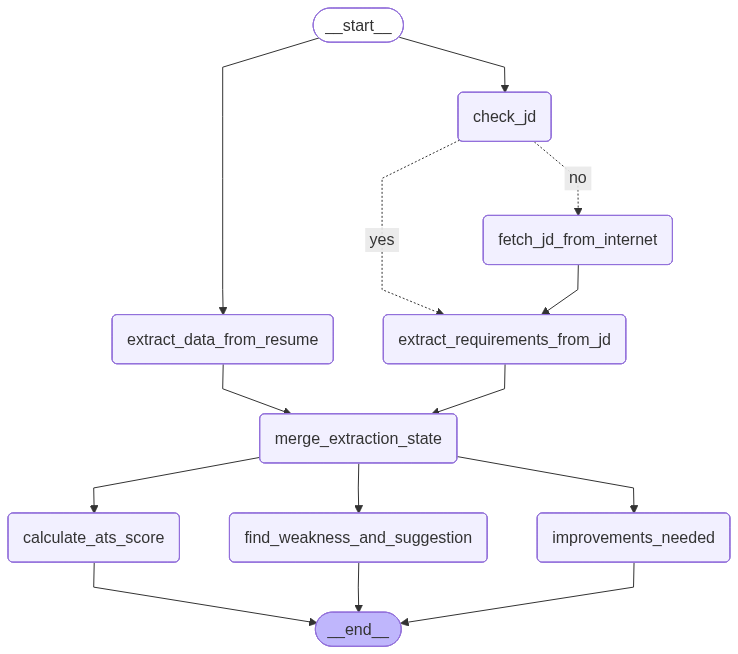

In [14]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

In [14]:
jd = """
We are seeking a highly motivated AI/ML Engineer to join our data science team. 
The ideal candidate should have strong proficiency in machine learning, deep learning, and data analytics, with experience building and deploying AI solutions.

Required Skills:
- Programming Languages: Python, R, Java
- Machine Learning: Scikit-learn, XGBoost, LightGBM
- Deep Learning: TensorFlow, PyTorch, Keras
- Data Handling: NumPy, Pandas, SQL
- Data Visualization: Matplotlib, Seaborn, Plotly
- Cloud & Tools: AWS, Google Cloud Platform, Docker, Git
- APIs & Deployment: REST APIs, Flask, FastAPI
- Soft Skills: Problem-solving, analytical thinking, teamwork

Preferred Experience:
- Developing and deploying ML/DL models
- Natural Language Processing (NLP) or Computer Vision projects
- Data preprocessing, feature engineering, and model optimization
- Writing clean, modular, and testable code
"""


In [15]:

response = agent.invoke({
    'resume_path' : 'Resume_DSAI.pdf',
    'jd_data' : jd
})


In [16]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='eac3297f-ac8f-41a6-b8f2-672bce7a8329'),
  HumanMessage(content='\nWe are seeking a highly motivated AI/ML Engineer to join our data science team. \nThe ideal candidate should have strong proficiency in machine learning, deep learning, and data analytics, with experience building and deploying AI solutions.\n\nRequired Skills:\n- Programming Languages: Python, R, Java\n- Machine Learning: Scikit-learn, XGBoost, LightGBM\n- Deep Learning: TensorFlow, PyTorch, Keras\n- Data Handling: NumPy, Pandas, SQL\n- Data Visualization: Matplotlib, Seaborn, Plotly\n- Cloud & Tools: AWS, Google Cloud Platform, Docker, Git\n- APIs & Deployment: REST APIs, Flask, FastAPI\n- Soft Skills: Problem-solving, analytical thinking, teamwork\n\nPreferred Experience:\n- Developing and deploying ML/DL models\n- Natural Language Processing (NLP) or Computer Vision projects\n- Data preprocessing, 

In [17]:
response['skill_requirements']

'Technical Skills:\n1. Python\n2. R\n3. Java\n4. Scikit-learn\n5. XGBoost\n6. LightGBM\n7. TensorFlow\n8. PyTorch\n9. Keras\n10. NumPy\n11. Pandas\n12. SQL\n13. Matplotlib\n14. Seaborn\n15. Plotly\n16. REST APIs\n17. Flask\n18. FastAPI\n\nTools and Technologies:\n1. AWS\n2. Google Cloud Platform\n3. Docker\n4. Git\n\nSoft Skills:\n1. Problem-solving\n2. Analytical thinking\n3. Teamwork\n\nDomain Knowledge:\n1. AI\n2. Machine Learning\n3. Data Science\n4. Data Analytics\n5. Deep Learning\n6. Natural Language Processing (NLP)\n7. Computer Vision\n\nOther Requirements:\n1. Experience in developing and deploying ML/DL models\n2. Experience in NLP or Computer Vision projects\n3. Experience in data preprocessing, feature engineering, and model optimization\n4. Ability to write clean, modular, and testable code'

In [18]:
jd ='''
Position: Web Developer
Experience: 0–2 years
Responsibilities:
- Develop web applications using HTML, CSS, and JavaScript.
- Build back-end APIs using Python (Django/Flask) or Node.js.
- Collaborate with designers to implement UI/UX.
- Optimize applications for speed and scalability.
- Maintain and update existing websites.
Required Skills:
- Proficient in HTML, CSS, JavaScript.
- Knowledge of Python or Node.js.

- Understanding of REST APIs and version control (Git). 
Preferred Skills:
- Experience with React, Angular, or Vue.js.
- Knowledge of cloud deployment (AWS, Azure).'''

In [19]:
initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)


In [20]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='0ebad62f-5af6-4659-9564-dab234878a78'),
  HumanMessage(content='\nPosition: Web Developer\nExperience: 0–2 years\nResponsibilities:\n- Develop web applications using HTML, CSS, and JavaScript.\n- Build back-end APIs using Python (Django/Flask) or Node.js.\n- Collaborate with designers to implement UI/UX.\n- Optimize applications for speed and scalability.\n- Maintain and update existing websites.\nRequired Skills:\n- Proficient in HTML, CSS, JavaScript.\n- Knowledge of Python or Node.js.\n\n- Understanding of REST APIs and version control (Git). \nPreferred Skills:\n- Experience with React, Angular, or Vue.js.\n- Knowledge of cloud deployment (AWS, Azure).', additional_kwargs={}, response_metadata={}, id='f40badf8-0c23-42e1-8c53-eff0ec759664')],
 'jd_approved': 'yes',
 'skill_requirements': 'Technical Skills:\n1. HTML\n2. CSS\n3. JavaScript\n4. Python\n5. Django\n6. 

In [21]:
jd = '''
Position: Physics Research Assistant
Experience: 0–2 years

Responsibilities:

Assist in conducting physics experiments and collecting experimental data.

Analyze physical systems and interpret results using scientific methods.

Support researchers in designing experiments and simulations.

Document experimental procedures and research findings.

Collaborate with research teams to solve complex physical problems.

Required Skills:

Strong understanding of fundamental physics concepts.

Analytical thinking and problem-solving ability.

Ability to interpret scientific data and experimental results.

Good documentation and research skills.

Preferred Skills:

Experience working in laboratory environments.
'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)


In [22]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='45e50623-084f-4ecd-8aae-e63dbb3c68d3'),
  HumanMessage(content='\nPosition: Physics Research Assistant\nExperience: 0–2 years\n\nResponsibilities:\n\nAssist in conducting physics experiments and collecting experimental data.\n\nAnalyze physical systems and interpret results using scientific methods.\n\nSupport researchers in designing experiments and simulations.\n\nDocument experimental procedures and research findings.\n\nCollaborate with research teams to solve complex physical problems.\n\nRequired Skills:\n\nStrong understanding of fundamental physics concepts.\n\nAnalytical thinking and problem-solving ability.\n\nAbility to interpret scientific data and experimental results.\n\nGood documentation and research skills.\n\nPreferred Skills:\n\nExperience working in laboratory environments.\n', additional_kwargs={}, response_metadata={}, id='4ba59f8a-baa8-48a9-813

In [23]:
jd = '''
Position: Data Scientist
Experience: 0–2 years

Responsibilities:

Build and train machine learning models for predictive analytics.

Perform data preprocessing, feature engineering, and model evaluation.

Conduct exploratory data analysis (EDA) to extract insights from datasets.

Develop and evaluate deep learning models for complex prediction tasks.

Collaborate with teams to deploy data-driven solutions.

Required Skills:

Machine learning and supervised learning techniques.

Experience with neural networks and deep learning frameworks.

Data preprocessing and exploratory data analysis.

Model evaluation and performance optimization.

Preferred Skills:

Experience working with NLP systems.

Knowledge of generative AI systems.

Experience working with large datasets.
'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [24]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='7ad24bcb-aed2-46f3-9502-64860641ca63'),
  HumanMessage(content='\nPosition: Data Scientist\nExperience: 0–2 years\n\nResponsibilities:\n\nBuild and train machine learning models for predictive analytics.\n\nPerform data preprocessing, feature engineering, and model evaluation.\n\nConduct exploratory data analysis (EDA) to extract insights from datasets.\n\nDevelop and evaluate deep learning models for complex prediction tasks.\n\nCollaborate with teams to deploy data-driven solutions.\n\nRequired Skills:\n\nMachine learning and supervised learning techniques.\n\nExperience with neural networks and deep learning frameworks.\n\nData preprocessing and exploratory data analysis.\n\nModel evaluation and performance optimization.\n\nPreferred Skills:\n\nExperience working with NLP systems.\n\nKnowledge of generative AI systems.\n\nExperience working with large datasets.\n'

In [26]:
jd = '''Job Title: AI / Machine Learning Engineer (Entry Level)

Experience: 0–2 years

Job Description:
We are looking for a motivated AI / Machine Learning Engineer to assist in developing intelligent systems and data-driven applications. The candidate will work on building machine learning models, analyzing data, and integrating AI solutions into software applications.

Responsibilities:

Develop and train machine learning models for prediction and classification tasks.

Perform data preprocessing, exploratory data analysis (EDA), and feature engineering.

Build NLP pipelines for text processing and language-based applications.

Evaluate model performance and improve model accuracy.

Work with large datasets and perform data analysis and visualization.

Collaborate with engineering teams to integrate AI models into applications.

Required Skills:

Strong programming knowledge in Python.

Knowledge of machine learning concepts such as supervised learning, neural networks, and model evaluation.

Experience with machine learning libraries such as PyTorch and Scikit-learn.

Experience with data analysis tools like Pandas, Matplotlib, and Seaborn.

Knowledge of data preprocessing and exploratory data analysis techniques.

Understanding of NLP libraries such as NLTK.

Familiarity with databases such as MySQL, SQLite, or PostgreSQL.

Preferred Skills:

Experience working with LLM frameworks such as LangChain or LangGraph.

Knowledge of generative AI systems and AI pipelines.

Familiarity with Git-based version control and collaborative development.

Experience working with Jupyter Notebook or similar development tools.'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [27]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='fd315c9f-c621-4914-9a26-96b58b123ba7'),
  HumanMessage(content='Job Title: AI / Machine Learning Engineer (Entry Level)\n\nExperience: 0–2 years\n\nJob Description:\nWe are looking for a motivated AI / Machine Learning Engineer to assist in developing intelligent systems and data-driven applications. The candidate will work on building machine learning models, analyzing data, and integrating AI solutions into software applications.\n\nResponsibilities:\n\nDevelop and train machine learning models for prediction and classification tasks.\n\nPerform data preprocessing, exploratory data analysis (EDA), and feature engineering.\n\nBuild NLP pipelines for text processing and language-based applications.\n\nEvaluate model performance and improve model accuracy.\n\nWork with large datasets and perform data analysis and visualization.\n\nCollaborate with engineering teams to

In [28]:
jd = '''Job Title: AI / Machine Learning Engineer (Entry Level)

Location: India
Experience: 0–2 Years

Job Description

We are seeking a passionate AI / Machine Learning Engineer to design and develop intelligent systems that leverage machine learning, natural language processing, and data-driven decision-making. The candidate will work on building scalable AI solutions, developing machine learning models, and implementing data pipelines for real-world applications.

Responsibilities

Develop machine learning and deep learning models for prediction, classification, and recommendation systems.

Perform data preprocessing, feature engineering, and exploratory data analysis (EDA).

Build and evaluate models using modern machine learning frameworks.

Develop NLP pipelines for text processing and conversational AI systems.

Design AI workflows and reasoning pipelines for intelligent applications.

Work with structured and unstructured datasets for model training and evaluation.

Visualize and interpret data to extract meaningful insights.

Maintain databases for storing and retrieving application data.

Collaborate with development teams to integrate AI models into software systems.

Conduct experiments to improve model performance and scalability.

Required Skills

Strong programming skills in Python.

Understanding of machine learning algorithms and neural networks.

Experience with PyTorch or similar deep learning frameworks.

Knowledge of data preprocessing, model evaluation, and supervised learning.

Experience with data analysis libraries such as Pandas, Matplotlib, and Seaborn.

Understanding of natural language processing concepts and text processing.

Knowledge of databases such as MySQL, SQLite, or PostgreSQL.

Familiarity with version control systems and collaborative development workflows.

Preferred Skills

Experience building LLM-based applications or conversational AI systems.

Knowledge of AI workflow orchestration or agent-based systems.

Experience working with memory-augmented AI architectures.

Familiarity with data-driven decision support systems.

Experience designing scalable AI systems and modular architectures.

Education

Bachelor's degree in Computer Science, Artificial Intelligence, Data Science, or a related field.

Ideal Candidate

Strong interest in Artificial Intelligence, Machine Learning, NLP, and Generative AI.

Experience working on AI projects involving real-world datasets.

Ability to design scalable and modular AI systems.

Strong analytical thinking and problem-solving skills'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [29]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='5fab33ca-cb9f-4d49-93be-492ab082bf9f'),
  HumanMessage(content="Job Title: AI / Machine Learning Engineer (Entry Level)\n\nLocation: India\nExperience: 0–2 Years\n\nJob Description\n\nWe are seeking a passionate AI / Machine Learning Engineer to design and develop intelligent systems that leverage machine learning, natural language processing, and data-driven decision-making. The candidate will work on building scalable AI solutions, developing machine learning models, and implementing data pipelines for real-world applications.\n\nResponsibilities\n\nDevelop machine learning and deep learning models for prediction, classification, and recommendation systems.\n\nPerform data preprocessing, feature engineering, and exploratory data analysis (EDA).\n\nBuild and evaluate models using modern machine learning frameworks.\n\nDevelop NLP pipelines for text processing and co

In [30]:
jd = '''Job Title: Geologist
Job Overview

We are seeking a motivated Geologist to join our exploration and research team. The candidate will be responsible for studying the Earth’s composition, structure, and processes to support mineral exploration, environmental assessment, and geological research. The role involves fieldwork, laboratory analysis, and interpretation of geological data.

Key Responsibilities

Conduct geological surveys and field investigations to study rock formations, soil samples, and mineral deposits.

Collect and analyze rock, soil, and groundwater samples for geological interpretation.

Prepare geological maps, cross-sections, and reports describing geological structures.

Use GIS tools and geological modeling software to analyze spatial geological data.

Assist in mineral and natural resource exploration projects.

Collaborate with environmental scientists and engineers for environmental impact assessments.

Interpret geological data to support mining, petroleum, and environmental projects.

Maintain accurate documentation of field observations and laboratory results.

Required Skills

Strong knowledge of geology, mineralogy, and stratigraphy

Understanding of sedimentology and structural geology

Ability to analyze geological samples and laboratory data

Experience with GIS and geological mapping tools

Knowledge of remote sensing and geological survey techniques

Strong analytical and problem-solving skills

Good written and verbal communication skills

Preferred Qualifications

Bachelor's or Master’s degree in Geology, Earth Science, or Geoscience

Experience with geological modeling software (e.g., Surfer, ArcGIS, RockWorks)

Knowledge of environmental geology or hydrogeology

Previous fieldwork or research experience in geological surveys

Tools & Technologies

ArcGIS / QGIS

RockWorks

Surfer

Remote sensing tools

Geological data analysis software

Experience

0–2 years experience in geological research, mineral exploration, or environmental geology (fresh graduates with fieldwork experience are encouraged to apply).'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [31]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='4c3259d6-c6fd-4e6e-b478-f38bd803335a'),
  HumanMessage(content="Job Title: Geologist\nJob Overview\n\nWe are seeking a motivated Geologist to join our exploration and research team. The candidate will be responsible for studying the Earth’s composition, structure, and processes to support mineral exploration, environmental assessment, and geological research. The role involves fieldwork, laboratory analysis, and interpretation of geological data.\n\nKey Responsibilities\n\nConduct geological surveys and field investigations to study rock formations, soil samples, and mineral deposits.\n\nCollect and analyze rock, soil, and groundwater samples for geological interpretation.\n\nPrepare geological maps, cross-sections, and reports describing geological structures.\n\nUse GIS tools and geological modeling software to analyze spatial geological data.\n\nAssist in mineral 

In [32]:
jd = '''Job Title: AI / Machine Learning Engineer (Entry Level)
Job Overview

We are seeking a highly motivated AI / Machine Learning Engineer to join our research and development team. The candidate will work on designing intelligent systems using machine learning, deep learning, and large language models (LLMs) to solve real-world problems. The role involves building scalable AI pipelines, developing data-driven models, and experimenting with modern AI frameworks for innovative applications.

Key Responsibilities

Develop and implement machine learning models for prediction, classification, and recommendation systems.

Build deep learning models using frameworks such as PyTorch or TensorFlow.

Design and implement NLP pipelines and conversational AI systems.

Work with large language models (LLMs) to develop intelligent agents and generative AI applications.

Perform data preprocessing, exploratory data analysis (EDA), and feature engineering.

Develop AI systems capable of multi-step reasoning and automated decision-making.

Implement scalable ML pipelines and model evaluation frameworks.

Collaborate with cross-functional teams to integrate AI solutions into real-world applications.

Required Skills

Strong programming skills in Python

Knowledge of Machine Learning algorithms and model evaluation techniques

Experience with Deep Learning frameworks such as PyTorch or TensorFlow

Understanding of Natural Language Processing (NLP)

Experience with data analysis and visualization tools (Pandas, Matplotlib, Seaborn)

Knowledge of data preprocessing and exploratory data analysis (EDA)

Familiarity with Git and collaborative software development

Preferred Qualifications

Experience with LangChain, LangGraph, or LLM orchestration frameworks

Knowledge of Generative AI and memory-augmented AI systems

Experience building AI agents or conversational systems

Knowledge of database systems such as MySQL, PostgreSQL, or SQLite

Exposure to cloud-based AI deployment or scalable architectures

Tools & Technologies

Python

PyTorch / TensorFlow

Scikit-learn

Pandas, NumPy

LangChain / LangGraph

Git / GitHub

Jupyter Notebook

SQL Databases

Education

Bachelor’s degree in Computer Science, Artificial Intelligence, Data Science, or related field

Experience

0–2 years experience in Machine Learning, AI development, or research projects

Strong academic projects in AI, NLP, or intelligent systems are highly preferred.'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [33]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='718f06de-657b-48f5-a13b-dd14d8a16800'),
  HumanMessage(content='Job Title: AI / Machine Learning Engineer (Entry Level)\nJob Overview\n\nWe are seeking a highly motivated AI / Machine Learning Engineer to join our research and development team. The candidate will work on designing intelligent systems using machine learning, deep learning, and large language models (LLMs) to solve real-world problems. The role involves building scalable AI pipelines, developing data-driven models, and experimenting with modern AI frameworks for innovative applications.\n\nKey Responsibilities\n\nDevelop and implement machine learning models for prediction, classification, and recommendation systems.\n\nBuild deep learning models using frameworks such as PyTorch or TensorFlow.\n\nDesign and implement NLP pipelines and conversational AI systems.\n\nWork with large language models (LLMs)

In [34]:
jd = '''
Job Title

AI / Machine Learning Engineer (Entry Level)

Job Overview

We are seeking a highly motivated AI / Machine Learning Engineer to join our research and development team. The candidate will work on designing intelligent systems using machine learning, deep learning, and large language models (LLMs) to solve real-world problems. The role involves building scalable AI pipelines, developing data-driven models, and experimenting with modern AI frameworks to create innovative AI-powered applications.

Key Responsibilities

Develop and implement machine learning models for prediction, classification, and recommendation systems.

Build deep learning models using frameworks such as PyTorch or TensorFlow.

Design and implement NLP pipelines and conversational AI systems.

Work with large language models (LLMs) to develop intelligent agents and generative AI applications.

Perform data preprocessing, feature engineering, and exploratory data analysis (EDA).

Develop AI systems capable of multi-step reasoning and automated decision-making.

Implement scalable ML pipelines and robust model evaluation frameworks.

Collaborate with cross-functional teams to integrate AI solutions into real-world applications.

Required Skills

Strong programming skills in Python

Knowledge of Machine Learning algorithms and model evaluation techniques

Experience with Deep Learning frameworks such as PyTorch or TensorFlow

Understanding of Natural Language Processing (NLP)

Experience with data analysis and visualization tools (Pandas, Matplotlib, Seaborn)

Knowledge of data preprocessing and exploratory data analysis (EDA)

Familiarity with Git and collaborative software development

Preferred Qualifications

Experience with LangChain, LangGraph, or LLM orchestration frameworks

Knowledge of Generative AI and memory-augmented AI systems

Experience building AI agents or conversational systems

Knowledge of database systems such as MySQL, PostgreSQL, or SQLite

Exposure to cloud-based AI deployment or scalable architectures

Tools & Technologies

Python

PyTorch / TensorFlow

Scikit-learn

Pandas, NumPy

LangChain / LangGraph

Git / GitHub

Jupyter Notebook

SQL Databases

Education

Bachelor’s degree in Computer Science, Artificial Intelligence, Data Science, or a related field.

Experience

0–2 years experience in Machine Learning, AI development, or research projects.

Strong academic or personal projects in AI, NLP, or intelligent systems are highly preferred.
'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [35]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='76b16d14-64ee-4e74-a8cf-ccd301123e83'),
  HumanMessage(content='\nJob Title\n\nAI / Machine Learning Engineer (Entry Level)\n\nJob Overview\n\nWe are seeking a highly motivated AI / Machine Learning Engineer to join our research and development team. The candidate will work on designing intelligent systems using machine learning, deep learning, and large language models (LLMs) to solve real-world problems. The role involves building scalable AI pipelines, developing data-driven models, and experimenting with modern AI frameworks to create innovative AI-powered applications.\n\nKey Responsibilities\n\nDevelop and implement machine learning models for prediction, classification, and recommendation systems.\n\nBuild deep learning models using frameworks such as PyTorch or TensorFlow.\n\nDesign and implement NLP pipelines and conversational AI systems.\n\nWork with large

In [36]:
jd = '''Job Title

Machine Learning / Generative AI Engineer (Entry Level)

Job Overview

We are looking for a passionate Machine Learning and Generative AI Engineer to develop intelligent systems using machine learning, deep learning, and large language models (LLMs). The candidate will work on building NLP-based applications, conversational AI agents, and data-driven ML models to solve real-world problems.

Key Responsibilities

Develop machine learning models using Python, PyTorch, and Scikit-learn for prediction and intelligent decision systems.

Build NLP-based applications including conversational agents and multilingual language systems.

Design and implement LLM-powered AI agents using LangChain and LangGraph.

Work on memory-augmented AI systems and LLM orchestration frameworks.

Perform data preprocessing, exploratory data analysis (EDA), and model evaluation using Pandas, Matplotlib, and Seaborn.

Develop AI-driven applications capable of reasoning and multi-step decision making.

Build scalable AI architectures using modular system design and persistent memory mechanisms.

Collaborate with teams to build real-world AI applications involving intelligent automation and recommendation systems.

Required Skills

Strong programming skills in Python

Knowledge of Machine Learning and Deep Learning concepts

Experience with PyTorch and Scikit-learn

Understanding of Natural Language Processing (NLP)

Experience with LangChain and LangGraph frameworks

Knowledge of data preprocessing and exploratory data analysis (EDA)

Familiarity with Git and GitHub

Preferred Skills

Experience building LLM-based conversational AI systems

Knowledge of Generative AI architectures and intelligent agents

Experience with database systems such as MySQL, PostgreSQL, or SQLite

Familiarity with machine learning research and experimentation

Tools & Technologies

Python

PyTorch

Scikit-learn

Pandas

Matplotlib

Seaborn

LangChain

LangGraph

Jupyter Notebook

Git / GitHub

MySQL / SQLite / PostgreSQL

Education

Bachelor’s degree in Computer Science, Artificial Intelligence, Data Science, or related field.

Experience

0–2 years experience in Machine Learning, NLP, Generative AI, or AI system development.

Strong academic or personal projects involving AI agents, ML models, or NLP systems are preferred.'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [37]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='2c85a5bc-3da3-49c9-9424-7a4b078f9433'),
  HumanMessage(content='Job Title\n\nMachine Learning / Generative AI Engineer (Entry Level)\n\nJob Overview\n\nWe are looking for a passionate Machine Learning and Generative AI Engineer to develop intelligent systems using machine learning, deep learning, and large language models (LLMs). The candidate will work on building NLP-based applications, conversational AI agents, and data-driven ML models to solve real-world problems.\n\nKey Responsibilities\n\nDevelop machine learning models using Python, PyTorch, and Scikit-learn for prediction and intelligent decision systems.\n\nBuild NLP-based applications including conversational agents and multilingual language systems.\n\nDesign and implement LLM-powered AI agents using LangChain and LangGraph.\n\nWork on memory-augmented AI systems and LLM orchestration frameworks.\n\nPerfo

In [38]:
jd = '''Job Title

Data Analyst (Entry Level)

Job Overview

We are looking for a motivated Data Analyst to help analyze datasets and generate insights that support business decision-making. The candidate will work with structured data, perform data analysis, and create reports and visualizations to communicate findings effectively.

Key Responsibilities

Collect, clean, and organize datasets from different sources.

Perform data preprocessing and exploratory data analysis (EDA).

Analyze trends and patterns in data to generate meaningful insights.

Create data visualizations and reports to present results.

Work with SQL databases to query and manage data.

Assist in building simple predictive models using basic machine learning techniques.

Communicate analytical results to team members and stakeholders.

Required Skills

Programming knowledge in Python or R

Experience with data analysis libraries such as Pandas and NumPy

Knowledge of SQL and relational databases

Understanding of statistics and data visualization techniques

Familiarity with Excel for data analysis

Preferred Skills

Basic knowledge of machine learning algorithms

Experience with data visualization tools such as Power BI or Tableau

Ability to interpret data and provide actionable insights

Tools & Technologies

Python / R

Pandas / NumPy

SQL

Excel

Power BI / Tableau

Education

Bachelor’s degree in Computer Science, Data Science, Statistics, or a related field.

Experience

0–2 years of experience in data analysis or related roles.

Academic'''

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

In [39]:
response

{'resume_path': 'Resume_DSAI.pdf',
 'jd_data': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='e7293d0e-aa82-4cfb-8f96-3471d15aaa94'),
  HumanMessage(content='Job Title\n\nData Analyst (Entry Level)\n\nJob Overview\n\nWe are looking for a motivated Data Analyst to help analyze datasets and generate insights that support business decision-making. The candidate will work with structured data, perform data analysis, and create reports and visualizations to communicate findings effectively.\n\nKey Responsibilities\n\nCollect, clean, and organize datasets from different sources.\n\nPerform data preprocessing and exploratory data analysis (EDA).\n\nAnalyze trends and patterns in data to generate meaningful insights.\n\nCreate data visualizations and reports to present results.\n\nWork with SQL databases to query and manage data.\n\nAssist in building simple predictive models using basic machine learning techniques.\n\nCommunicate analytical results to team members a

In [15]:
jd = 'ML Engineer'

initial_state = ResumeAnalysisState(
    resume_path='Resume_DSAI.pdf',
    jd_data=jd
)

response = agent.invoke(initial_state)

KeyError: 'skill_requirements'

In [16]:
response =fetch_jd_from_internet({'jd_data':'ML Engineer'})

In [18]:
extract_requirements_from_jd(
    {
        'jd_data' : response
    }
)

{'skill_requirements': 'Technical Skills:\n1. Python\n2. TensorFlow\n3. PyTorch\n4. scikit-learn\n5. Docker\n6. Kubernetes\n7. Git\n\nTools and Technologies:\n1. Jenkins\n2. GitHub Actions\n3. GitLab CI\n4. AWS\n5. GCP\n6. Azure\n7. MLflow\n8. Kubeflow\n9. Airflow\n10. Spark\n11. Prometheus\n12. Grafana\n\nSoft Skills:\n1. Problem-solving\n2. Debugging\n3. Clean code writing\n4. Maintainable code writing\n5. Documentation\n6. Collaboration\n7. Communication\n\nDomain Knowledge:\n1. Machine Learning\n2. Data Science\n3. Data Engineering\n4. Software Development\n\nOther Requirements:\n1. Strong programming skills\n2. Experience with ML frameworks\n3. Familiarity with CI/CD pipelines\n4. Understanding of cloud platforms\n5. Ability to write clean, maintainable code and documentation\n6. Experience with MLOps tools (preferred)\n7. Experience with A/B testing and feature flagging (preferred)'}